In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from sklearn.ensemble import RandomForestRegressor

In [130]:
def load_model_and_encoder(model_path, encoder_path):
    model = joblib.load(model_path)
    encoder = joblib.load(encoder_path)
    return model, encoder

In [131]:
model = joblib.load(r'./Model/final_model_gbm.joblib')
ohe = joblib.load(r'./Model/encoder_preciptype.joblib')

In [132]:
df_forecast = pd.read_csv(r'./Data/weather_data_forecast.csv')
df_forecast.head()

,datetime,datetimeEpoch,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,sunrise,sunriseEpoch,sunset,sunsetEpoch,moonphase,conditions,description,icon,stations,source
0,2025-07-12,1752271200,20.3,13.0,16.7,20.3,13.0,16.7,12.0,75.1,...,04:55:05,1752288905,20:52:05,1752346325,0.56,"Rain, Partially cloudy",Partly cloudy throughout the day with rain.,rain,"['D4554', 'LKMT', 'LKKU', 'LZZI']",comb
1,2025-07-13,1752357600,26.2,15.4,20.5,26.2,15.4,20.5,13.2,64.2,...,04:56:07,1752375367,20:51:16,1752432676,0.59,"Rain, Partially cloudy",Partly cloudy throughout the day with late aft...,rain,NaN,fcst
2,2025-07-14,1752444000,26.7,15.6,21.5,26.7,15.6,21.5,15.7,71.4,...,04:57:09,1752461829,20:50:26,1752519026,0.63,"Rain, Partially cloudy",Partly cloudy throughout the day with storms p...,rain,NaN,fcst
3,2025-07-15,1752530400,25.3,15.7,20.3,25.3,15.7,20.3,15.2,74.0,...,04:58:14,1752548294,20:49:32,1752605372,0.66,"Rain, Partially cloudy",Becoming cloudy in the afternoon with a chance...,rain,NaN,fcst
4,2025-07-16,1752616800,19.3,12.7,16.1,19.3,12.7,16.1,11.6,75.5,...,04:59:20,1752634760,20:48:36,1752691716,0.70,"Rain, Partially cloudy",Partly cloudy throughout the day with a chance...,rain,NaN,fcst


In [133]:
columns = {'cloudcover',
 'datetime',
 'dew',
 'feelslike',
 'feelslikemax',
 'feelslikemin',
 'humidity',
 'precip',
 'precipcover',
 'preciptype',
 'pressure',
 'snow',
 'snowdepth',
 'solarenergy',
 'solarradiation',
 'sunrise',
 'sunset',
 'temp',
 'tempmax',
 'tempmin',
 'uvindex',
 'visibility',
 'winddir',
 'windgust',
 'windspeed'}

In [134]:
df_forecast_filtered = df_forecast[list(columns)].copy()

In [135]:
df_forecast_filtered['datetime'] = pd.to_datetime(df_forecast_filtered['datetime'])

In [136]:
df_forecast_filtered['month'] = df_forecast_filtered['datetime'].dt.month
df_forecast_filtered['dayofyear'] = df_forecast_filtered['datetime'].dt.dayofyear

df_forecast_filtered['sin_month'] = np.sin(2 * np.pi * df_forecast_filtered['month'] / 12)
df_forecast_filtered['cos_month'] = np.cos(2 * np.pi * df_forecast_filtered['month'] / 12)


df_forecast_filtered['sin_dayofyear'] = np.sin(2 * np.pi * df_forecast_filtered['dayofyear'] / 365)
df_forecast_filtered['cos_dayofyear'] = np.cos(2 * np.pi * df_forecast_filtered['dayofyear'] / 365)

df_forecast_filtered['year'] = df_forecast_filtered['datetime'].dt.year

In [137]:
def time_to_seconds(t):
    """Převede časový string HH:MM:SS na počet sekund od půlnoci."""
    h, m, s = map(int, t.split(':'))
    return h*3600 + m*60 + s


df_forecast_filtered['sunset_seconds'] = df_forecast_filtered['sunset'].apply(time_to_seconds)
df_forecast_filtered['sunrise_seconds'] = df_forecast_filtered['sunrise'].apply(time_to_seconds)


seconds_in_day = 24*3600
df_forecast_filtered['sunset_sin'] = np.sin(2 * np.pi * df_forecast_filtered['sunset_seconds'] / seconds_in_day)
df_forecast_filtered['sunset_cos'] = np.cos(2 * np.pi * df_forecast_filtered['sunset_seconds'] / seconds_in_day)


df_forecast_filtered['sunrise_sin'] = np.sin(2 * np.pi * df_forecast_filtered['sunrise_seconds'] / seconds_in_day)
df_forecast_filtered['sunrise_cos'] = np.cos(2 * np.pi * df_forecast_filtered['sunrise_seconds'] / seconds_in_day)


df_forecast_filtered['day_length_seconds'] = df_forecast_filtered['sunset_seconds'] - df_forecast_filtered['sunrise_seconds']


df_forecast_filtered['day_length_hours'] = df_forecast_filtered['day_length_seconds'] / 3600

In [138]:
df_forecast_final = df_forecast_filtered.drop(columns=[ 'sunset', 'sunrise', 'month', 'dayofyear'])

In [139]:
df_forecast_final = df_forecast_final.drop(columns=['datetime'])

In [140]:
def encode_precip(df, ohe):
    df = df.copy()
    encoded = ohe.transform(df[['preciptype']])
    encoded_df = pd.DataFrame(
        encoded,
        columns=ohe.get_feature_names_out(['preciptype']),
        index=df.index
    )
    return pd.concat([df.drop(columns=['preciptype']), encoded_df], axis=1)

In [141]:
X_forecast_enc = encode_precip(df_forecast_final, ohe)

In [142]:
desired_order = [
    'winddir', 'feelslikemin', 'dew', 'windgust', 'precipcover', 'uvindex',
    'snow', 'solarenergy', 'visibility', 'precip', 'pressure', 'tempmin',
    'cloudcover', 'tempmax', 'windspeed', 'feelslikemax', 'temp',
    'feelslike', 'solarradiation', 'humidity', 'snowdepth', 'sin_month',
    'cos_month', 'sin_dayofyear', 'cos_dayofyear', 'year', 'sunset_seconds',
    'sunrise_seconds', 'sunset_sin', 'sunset_cos', 'sunrise_sin',
    'sunrise_cos', 'day_length_seconds', 'day_length_hours',
    "preciptype_['none']", "preciptype_['rain', 'snow']",
    "preciptype_['rain']", "preciptype_['snow']"
]

X_forecast_enc = X_forecast_enc[desired_order]

In [143]:
y_pred = model.predict(X_forecast_enc)

In [144]:
result_df = df_forecast[['datetime']].copy()
result_df['PV(kWh)_pred'] = y_pred

In [145]:
result_df

,datetime,PV(kWh)_pred
0,2025-07-12,23.352019
1,2025-07-13,41.874257
2,2025-07-14,41.028019
3,2025-07-15,34.499610
4,2025-07-16,22.893250
5,2025-07-17,24.412576
6,2025-07-18,44.561629
7,2025-07-19,46.729651
8,2025-07-20,42.586471
9,2025-07-21,46.087939


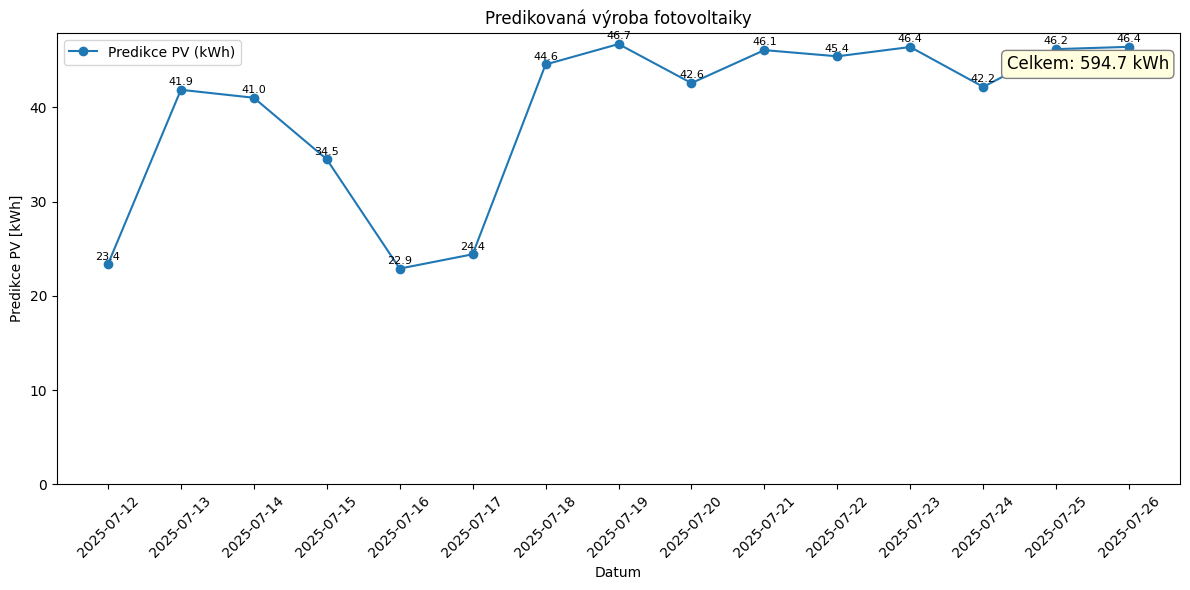

In [146]:



plt.figure(figsize=(12, 6))
plt.plot(result_df["datetime"], result_df["PV(kWh)_pred"], marker='o', label="Predikce PV (kWh)")


for x, y in zip(result_df["datetime"], result_df["PV(kWh)_pred"]):
    plt.text(x, y + 0.5, f"{y:.1f}", ha='center', fontsize=8, color='black')


plt.xlabel("Datum")
plt.ylabel("Predikce PV [kWh]")
plt.title("Predikovaná výroba fotovoltaiky")
plt.xticks(rotation=45)


plt.legend(loc="upper left")


total_pred = result_df["PV(kWh)_pred"].sum()
plt.text(
    0.99, 0.95,
    f"Celkem: {total_pred:.1f} kWh",
    transform=plt.gca().transAxes,
    fontsize=12,
    ha='right',
    va='top',
    bbox=dict(boxstyle="round,pad=0.3", edgecolor='gray', facecolor='lightyellow')
)

plt.tight_layout()
plt.grid(False)
plt.ylim(bottom = 0)
plt.show()


In [147]:
df_last_year = pd.read_csv(r'./Data/SEMS_data.csv', parse_dates=["Datum"])
df_last_year.head()

,Datum,Elektrárna,Klasifikace,Kapacita(kW),PV(kWh),Prodej(kWh),Koupit(kWh),Spotřeba(kWh),Spotřebováno v domácnosti(kWh),Vlastní poměr(%),Contribution Ratio(%),Příjem(CZK)
0,01.01.2024,HFVE Zapletal Simon,Úložiště baterie,7.6,1.2,0.11,14.12,20.01,5.89,98.17,29.44,6.0
1,02.01.2024,HFVE Zapletal Simon,Úložiště baterie,7.6,1.3,0.11,6.32,12.21,5.89,98.17,48.24,6.5
2,03.01.2024,HFVE Zapletal Simon,Úložiště baterie,7.6,1.9,0.12,5.51,12.19,6.68,98.24,54.80,9.5
3,04.01.2024,HFVE Zapletal Simon,Úložiště baterie,7.6,1.8,0.15,6.13,11.78,5.65,97.41,47.96,9.0
4,05.01.2024,HFVE Zapletal Simon,Úložiště baterie,7.6,4.5,0.88,5.14,14.76,9.62,91.62,65.18,22.5


In [148]:
df_last_year['Datum'] = df_last_year['Datum'].str.replace(r'\.', '-', regex=True)
df_last_year['Datum'] = pd.to_datetime(df_last_year['Datum'], dayfirst=True)
df_last_year

,Datum,Elektrárna,Klasifikace,Kapacita(kW),PV(kWh),Prodej(kWh),Koupit(kWh),Spotřeba(kWh),Spotřebováno v domácnosti(kWh),Vlastní poměr(%),Contribution Ratio(%),Příjem(CZK)
0,2024-01-01,HFVE Zapletal Simon,Úložiště baterie,7.6,1.2,0.11,14.12,20.01,5.89,98.17,29.44,6.0
1,2024-01-02,HFVE Zapletal Simon,Úložiště baterie,7.6,1.3,0.11,6.32,12.21,5.89,98.17,48.24,6.5
2,2024-01-03,HFVE Zapletal Simon,Úložiště baterie,7.6,1.9,0.12,5.51,12.19,6.68,98.24,54.80,9.5
3,2024-01-04,HFVE Zapletal Simon,Úložiště baterie,7.6,1.8,0.15,6.13,11.78,5.65,97.41,47.96,9.0
4,2024-01-05,HFVE Zapletal Simon,Úložiště baterie,7.6,4.5,0.88,5.14,14.76,9.62,91.62,65.18,22.5
...,...,...,...,...,...,...,...,...,...,...,...,...
664,2024-12-27,HFVE Zapletal Simon,Úložiště baterie,7.6,13.3,8.41,4.60,13.79,9.19,52.22,66.64,66.5
665,2024-12-28,HFVE Zapletal Simon,Úložiště baterie,7.6,11.0,5.76,5.40,14.14,8.74,60.28,61.81,55.0
666,2024-12-29,HFVE Zapletal Simon,Úložiště baterie,7.6,14.2,4.33,0.08,9.65,9.57,68.85,99.17,71.0
667,2024-12-30,HFVE Zapletal Simon,Úložiště baterie,7.6,13.1,2.08,0.07,13.29,13.22,86.41,99.47,65.5


In [149]:
df_last_year['day'] = df_last_year['Datum'].dt.day
df_last_year['month'] = df_last_year['Datum'].dt.month

result_df_expanded = result_df.copy()
result_df_expanded['datetime'] = pd.to_datetime(result_df_expanded['datetime'])
result_df_expanded['day'] = result_df_expanded['datetime'].dt.day
result_df_expanded['month'] = result_df_expanded['datetime'].dt.month

In [150]:
df_last_year_filtered = df_last_year.merge(
    result_df_expanded[['day', 'month']],
    on=['day', 'month'],
    how='inner'
)
df_last_year_filtered["Datum"] = pd.to_datetime(df_last_year_filtered["Datum"])

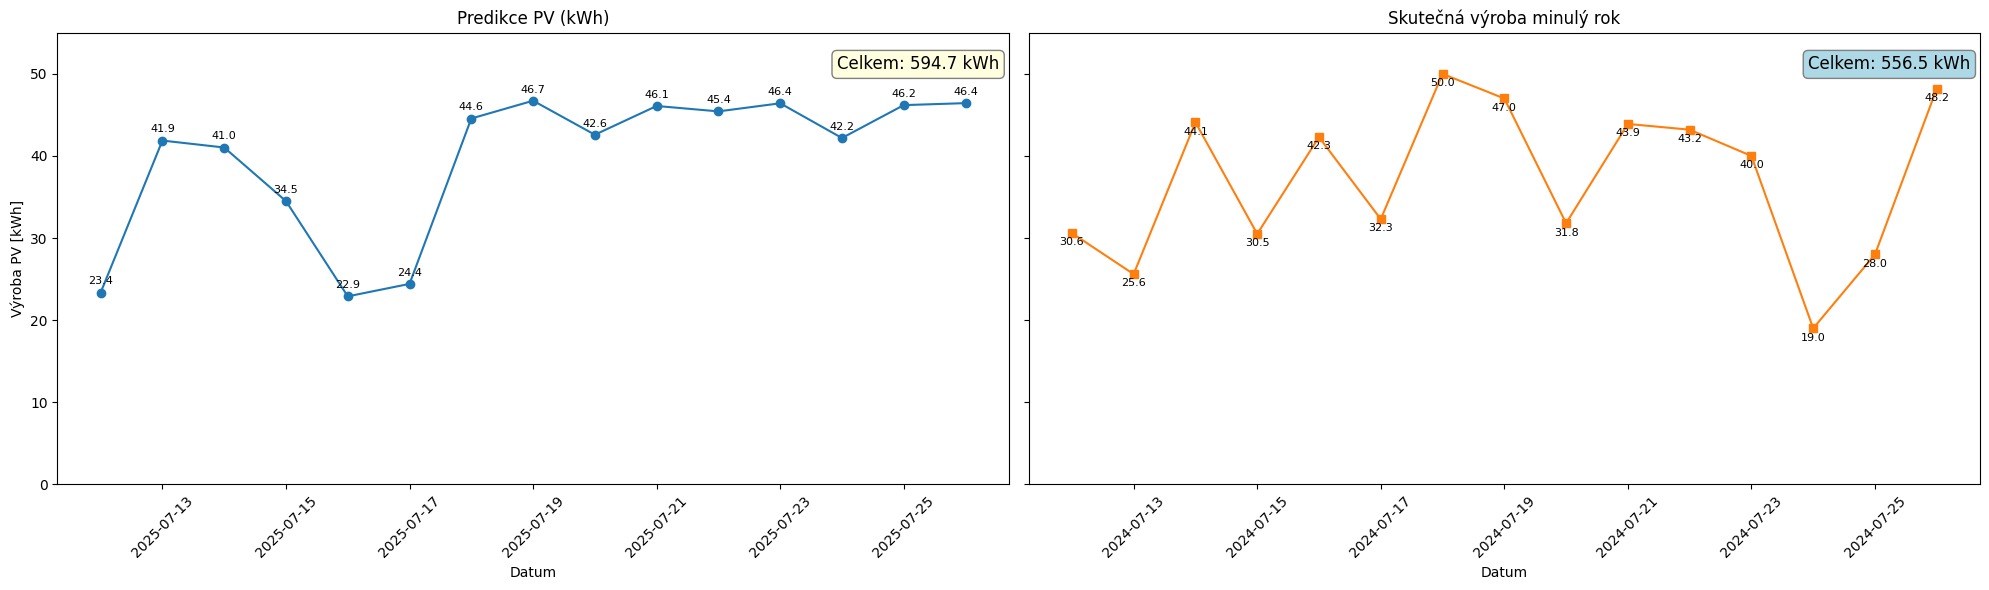

In [164]:
# Převod dat na datetime (pro jistotu)
result_df["datetime"] = pd.to_datetime(result_df["datetime"])
df_last_year_filtered["Datum"] = pd.to_datetime(df_last_year_filtered["Datum"])



# Spočítáme max hodnotu z obou datasetů
max_y = max(result_df["PV(kWh)_pred"].max(), df_last_year_filtered["PV(kWh)"].max())

fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

# Graf 1: Predikce aktuálního roku
axes[0].plot(result_df["datetime"], result_df["PV(kWh)_pred"], marker='o', color='tab:blue')
axes[0].set_title("Predikce PV (kWh)")
axes[0].set_xlabel("Datum")
axes[0].set_ylabel("Výroba PV [kWh]")
axes[0].set_ylim(0, max_y * 1.1)  # +10% pro rezervu nahoře
axes[0].tick_params(axis='x', rotation=45)

for x, y in zip(result_df["datetime"], result_df["PV(kWh)_pred"]):
    axes[0].text(x, y + max_y * 0.02, f"{y:.1f}", ha='center', fontsize=8, color='black')

total_pred = result_df["PV(kWh)_pred"].sum()
axes[0].text(
    0.99, 0.95,
    f"Celkem: {total_pred:.1f} kWh",
    transform=axes[0].transAxes,
    fontsize=12,
    ha='right',
    va='top',
    bbox=dict(boxstyle="round,pad=0.3", edgecolor='gray', facecolor='lightyellow')
)

# Graf 2: Historická výroba minulý rok
axes[1].plot(df_last_year_filtered["Datum"], df_last_year_filtered["PV(kWh)"], marker='s', color='tab:orange')
axes[1].set_title("Skutečná výroba minulý rok")
axes[1].set_xlabel("Datum")
axes[1].set_ylim(0, max_y * 1.1)  # Stejný limit jako první graf
axes[1].tick_params(axis='x', rotation=45)

for x, y in zip(df_last_year_filtered["Datum"], df_last_year_filtered["PV(kWh)"]):
    axes[1].text(x, y - max_y * 0.03, f"{y:.1f}", ha='center', fontsize=8, color='black')

total_actual = df_last_year_filtered["PV(kWh)"].sum()
axes[1].text(
    0.99, 0.95,
    f"Celkem: {total_actual:.1f} kWh",
    transform=axes[1].transAxes,
    fontsize=12,
    ha='right',
    va='top',
    bbox=dict(boxstyle="round,pad=0.3", edgecolor='gray', facecolor='lightblue')
)

plt.tight_layout()
plt.show()
